# Simple Home Run Prediction

This notebook will guide you through:
- Loading your pre-downloaded train and test datasets
- Data exploration and preprocessing
- Building a simple model to predict home runs


## Step 1: Load Train and Test Data
Place your train and test CSV files in this working directory. Update the filenames below if yours are different (e.g., `train.csv`, `test.csv`).


In [115]:
import pandas as pd

# Modify these filenames if your CSVs are differently named
train_file = 'train.csv'
test_file = 'test.csv'

df_train = pd.read_csv(train_file)
df_test = pd.read_csv(test_file)
df_train.head()


,uid,home_team,sz_top,sz_bot,pitch_type,release_pos_x,release_pos_y,release_pos_z,stand,p_throws,...,release_spin_rate,pfx_x,pfx_z,plate_x,plate_z,hc_x,hc_y,launch_speed,launch_angle,is_hr
0,0,LAA,3.35,1.61,CU,-2.14,53.69,6.48,R,R,...,2110,0.73,-0.79,-0.11,3.19,138.97,86.01,94.6,47,0
1,2,LAA,3.39,1.63,CH,1.83,54.15,5.94,R,L,...,1710,1.22,0.71,0.74,1.44,111.73,159.90,69.5,-30,0
2,4,LAA,3.46,1.59,CU,-2.32,53.99,6.43,L,R,...,2154,0.73,-0.67,-0.32,2.69,112.87,148.15,93.8,66,0
3,5,LAA,3.29,1.54,SL,-2.01,53.71,6.37,R,R,...,2209,0.50,0.98,-0.20,2.14,180.78,96.91,87.5,38,0
4,6,LAA,3.47,1.65,FF,-2.16,53.61,6.29,L,R,...,2230,-0.29,1.60,0.00,2.89,134.75,101.76,100.0,-2,0


## Step 2: Data Exploration and Cleaning
Quick look at available columns, drop missing data, and simple feature engineering.


In [116]:
# Explore shapes and columns
print(f"Train shape: {df_train.shape}")
print(f"Test shape: {df_test.shape}")
print(f"\nTarget distribution (is_hr):")
print(df_train['is_hr'].value_counts())
print(f"\nTarget balance:")
print(df_train['is_hr'].value_counts(normalize=True))
df_train.describe()


Train shape: (97309, 34)
Test shape: (20000, 33)

Target distribution (is_hr):
is_hr
0    93675
1     3634
Name: count, dtype: int64

Target balance:
is_hr
0    0.962655
1    0.037345
Name: proportion, dtype: float64


,uid,sz_top,sz_bot,release_pos_x,release_pos_y,release_pos_z,inning,outs_when_up,balls,strikes,...,release_spin_rate,pfx_x,pfx_z,plate_x,plate_z,hc_x,hc_y,launch_speed,launch_angle,is_hr
count,97309.000000,97309.000000,97309.000000,97309.000000,97309.000000,97309.000000,97309.000000,97309.00000,97309.000000,97309.000000,...,97309.000000,97309.000000,97309.000000,97309.000000,97309.000000,97309.000000,97309.000000,97309.000000,97309.000000,97309.000000
mean,58567.089981,3.382325,1.594078,-0.807896,54.187102,5.804391,4.921867,0.96654,1.099004,1.119670,...,2217.858091,-0.139049,0.630698,-0.009845,2.363408,126.304523,124.333252,87.886355,12.555077,0.037345
std,33877.962463,0.173003,0.097181,1.830800,0.444308,0.571972,2.561263,0.81644,1.005433,0.809693,...,333.162953,0.899282,0.700651,0.546433,0.579004,39.699922,40.884031,14.751177,29.354195,0.189607
min,0.000000,2.760000,1.220000,-4.840000,52.280000,0.910000,1.000000,0.00000,0.000000,0.000000,...,230.000000,-2.460000,-2.100000,-1.990000,0.300000,3.080000,7.950000,5.200000,-90.000000,0.000000
25%,29191.000000,3.270000,1.530000,-2.080000,53.900000,5.530000,3.000000,0.00000,0.000000,0.000000,...,2067.000000,-0.920000,0.210000,-0.400000,1.960000,101.980000,92.130000,79.500000,-6.000000,0.000000
50%,58557.000000,3.380000,1.590000,-1.500000,54.170000,5.860000,5.000000,1.00000,1.000000,1.000000,...,2248.000000,-0.230000,0.700000,-0.010000,2.350000,125.230000,129.540000,90.700000,13.000000,0.000000
75%,87896.000000,3.490000,1.660000,0.920000,54.480000,6.150000,7.000000,2.00000,2.000000,2.000000,...,2420.000000,0.580000,1.200000,0.380000,2.760000,153.540000,157.280000,98.900000,32.000000,0.000000
max,117308.000000,4.020000,1.930000,4.700000,57.350000,7.470000,15.000000,2.00000,3.000000,3.000000,...,3498.000000,2.360000,2.600000,1.840000,5.040000,246.630000,242.110000,122.400000,90.000000,1.000000


## Step 3: Data Preparation & Feature Engineering
We'll use the `is_hr` column as our target and select numeric features as predictors. The target will be renamed to `is_homerun` for clarity.


In [117]:
# Use the provided is_hr column as target
df_train['is_homerun'] = df_train['is_hr']
if 'is_hr' in df_test.columns:
    df_test['is_homerun'] = df_test['is_hr']

features = [
    'release_speed', 'release_pos_x', 'release_pos_y', 'release_pos_z', 
    'sz_top', 'sz_bot', 'spin_axis', 'release_spin_rate',
    'pfx_x', 'pfx_z', 'plate_x', 'plate_z',
    'hc_x', 'hc_y', 'launch_speed', 'launch_angle',
    'balls', 'strikes', 'pitch_number', 'at_bat_number', 'outs_when_up'
]
train_filtered = df_train.dropna(subset=features + ['is_homerun'])
test_filtered = df_test.dropna(subset=features)
X_train = train_filtered[features]
y_train = train_filtered['is_homerun']
X_test = test_filtered[features]
y_test = test_filtered['is_homerun'] if 'is_homerun' in df_test else None
X_train.head()


,release_speed,release_pos_x,release_pos_y,release_pos_z,sz_top,sz_bot,spin_axis,release_spin_rate,pfx_x,pfx_z,...,plate_z,hc_x,hc_y,launch_speed,launch_angle,balls,strikes,pitch_number,at_bat_number,outs_when_up
0,78.8,-2.14,53.69,6.48,3.35,1.61,30,2110,0.73,-0.79,...,3.19,138.97,86.01,94.6,47,0,2,5,4,0
1,86.4,1.83,54.15,5.94,3.39,1.63,118,1710,1.22,0.71,...,1.44,111.73,159.90,69.5,-30,0,1,2,2,1
2,78.6,-2.32,53.99,6.43,3.46,1.59,31,2154,0.73,-0.67,...,2.69,112.87,148.15,93.8,66,0,1,2,10,0
3,87.3,-2.01,53.71,6.37,3.29,1.54,179,2209,0.50,0.98,...,2.14,180.78,96.91,87.5,38,0,1,2,13,1
4,93.0,-2.16,53.61,6.29,3.47,1.65,197,2230,-0.29,1.60,...,2.89,134.75,101.76,100.0,-2,0,2,3,12,1


## Step 4: Modeling and Evaluation
Now we train a simple logistic regression model and evaluate predictions. If your test set does not have an `is_homerun` column, you can generate predictions for further evaluation.


TRAINING DATA OVERVIEW
Training set class distribution:
is_homerun
0    93675
1     3634
Name: count, dtype: int64

Class balance: is_homerun
0    0.962655
1    0.037345
Name: proportion, dtype: float64

Training logistic regression model...

MODEL PERFORMANCE METRICS (Validation Set)

Accuracy:  0.8815
Precision: 0.2317
Recall:    0.9381
F1-Score:  0.3716
ROC-AUC:   0.9656

------------------------------------------------------------
Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

       No HR       1.00      0.88      0.93     18735
          HR       0.23      0.94      0.37       727

    accuracy                           0.88     19462
   macro avg       0.61      0.91      0.65     19462
weighted avg       0.97      0.88      0.91     19462


------------------------------------------------------------
Confusion Matrix:
------------------------------------------------------------
[[16473  

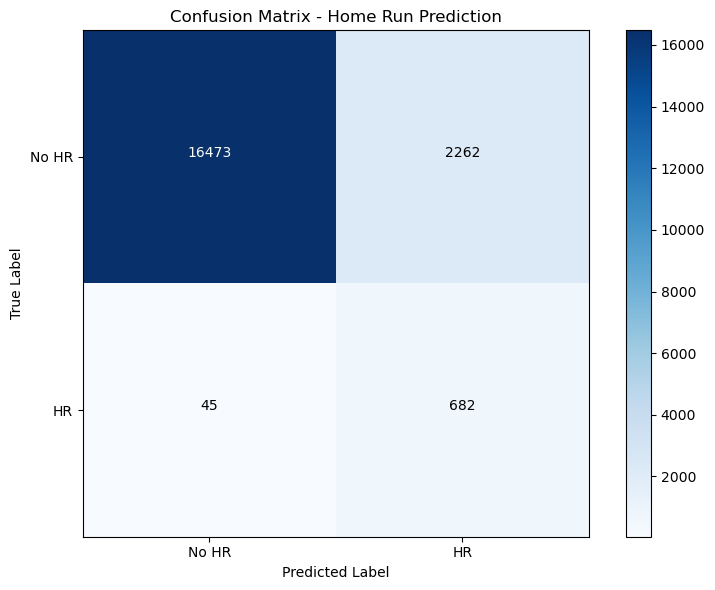

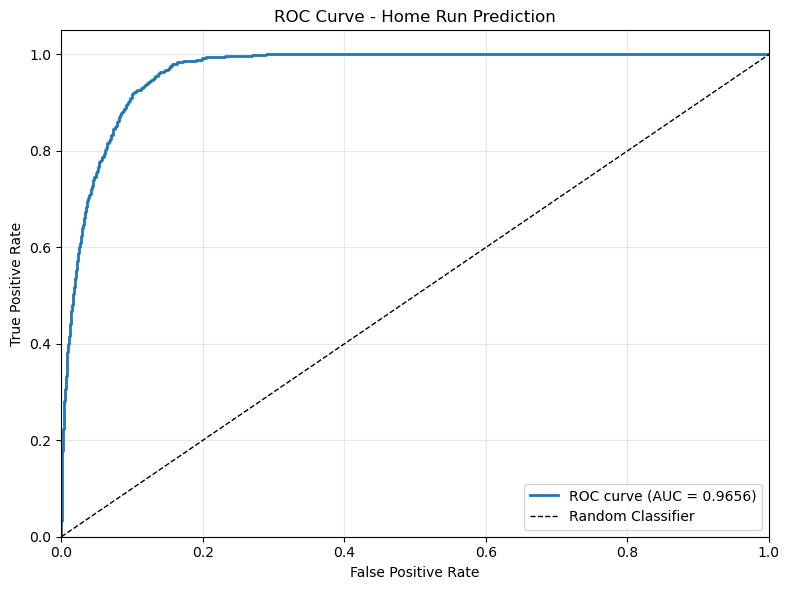


TEST SET PREDICTIONS

Prediction distribution: [17059  2941]
Predicted home runs: 2941 (14.70%)

First 10 predictions: [0 0 0 0 0 0 0 0 0 0]
First 10 probabilities: [1.75854372e-04 9.84337303e-13 8.56650300e-03 6.67959649e-06
 3.10946167e-08 4.27779347e-15 1.67798840e-04 7.82643064e-03
 3.85634232e-01 4.17315379e-02]

Average predicted probability: 0.1606

FEATURE IMPORTANCE ANALYSIS

Feature importances (absolute values, descending order):
 1. launch_speed         | Coefficient:  4.2455
 2. launch_angle         | Coefficient:  2.7965
 3. hc_y                 | Coefficient: -1.7912
 4. release_speed        | Coefficient: -0.2731
 5. sz_top               | Coefficient: -0.1911
 6. pitch_number         | Coefficient:  0.1579
 7. plate_z              | Coefficient:  0.1035
 8. pfx_x                | Coefficient: -0.0879
 9. hc_x                 | Coefficient: -0.0620
10. release_pos_z        | Coefficient: -0.0562
11. spin_axis            | Coefficient: -0.0562
12. sz_bot               |

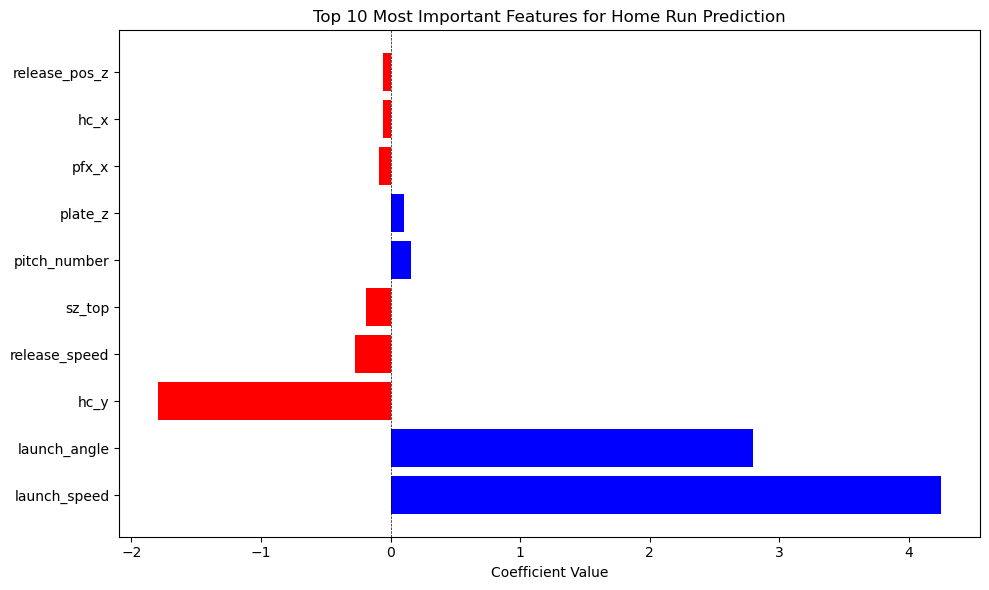

In [118]:
# Train model and comprehensive evaluation
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, 
                              accuracy_score, precision_score, recall_score, 
                              f1_score, roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# Check class distribution
print("="*60)
print("TRAINING DATA OVERVIEW")
print("="*60)
print(f"Training set class distribution:\n{y_train.value_counts()}\n")
print(f"Class balance: {y_train.value_counts(normalize=True)}\n")

# Create validation split from training data for proper evaluation
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Scale features for better convergence
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_split)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Train model with more iterations and class_weight to handle imbalance
print("Training logistic regression model...")
clf = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
clf.fit(X_train_scaled, y_train_split)

# Get predictions and probabilities on validation set
y_val_pred = clf.predict(X_val_scaled)
y_val_pred_proba = clf.predict_proba(X_val_scaled)[:, 1]

# Comprehensive evaluation on validation set
print("\n" + "="*60)
print("MODEL PERFORMANCE METRICS (Validation Set)")
print("="*60)
print(f"\nAccuracy:  {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred):.4f}")
print(f"Recall:    {recall_score(y_val, y_val_pred):.4f}")
print(f"F1-Score:  {f1_score(y_val, y_val_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_val, y_val_pred_proba):.4f}")

print("\n" + "-"*60)
print("Classification Report:")
print("-"*60)
print(classification_report(y_val, y_val_pred, target_names=['No HR', 'HR']))

print("\n" + "-"*60)
print("Confusion Matrix:")
print("-"*60)
cm = confusion_matrix(y_val, y_val_pred)
print(cm)
print(f"\nTrue Negatives:  {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives:  {cm[1,1]}")

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Home Run Prediction')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['No HR', 'HR'])
plt.yticks(tick_marks, ['No HR', 'HR'])
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_val, y_val_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'ROC curve (AUC = {roc_auc_score(y_val, y_val_pred_proba):.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Home Run Prediction')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Test set predictions
print("\n" + "="*60)
print("TEST SET PREDICTIONS")
print("="*60)
y_test_pred = clf.predict(X_test_scaled)
y_test_pred_proba = clf.predict_proba(X_test_scaled)[:, 1]

if y_test is not None and len(y_test) == len(y_test_pred):
    print(f"\nAccuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
    print(f"Recall:    {recall_score(y_test, y_test_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_test, y_test_pred):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_test, y_test_pred_proba):.4f}")
    print("\nClassification Report on Test Set:")
    print(classification_report(y_test, y_test_pred, target_names=['No HR', 'HR']))
else:
    print(f"\nPrediction distribution: {np.bincount(y_test_pred)}")
    print(f"Predicted home runs: {np.sum(y_test_pred)} ({np.sum(y_test_pred)/len(y_test_pred)*100:.2f}%)")
    print(f"\nFirst 10 predictions: {y_test_pred[:10]}")
    print(f"First 10 probabilities: {y_test_pred_proba[:10]}")
    print(f"\nAverage predicted probability: {np.mean(y_test_pred_proba):.4f}")

# Feature importances
print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)
feature_names = np.array(features)
coefs = clf.coef_[0]
importance = np.abs(coefs)
indices = np.argsort(importance)[::-1]

print("\nFeature importances (absolute values, descending order):")
for rank, idx in enumerate(indices):
    print(f"{rank+1:2}. {feature_names[idx]:20} | Coefficient: {coefs[idx]: .4f}")

# Visualize top features
top_n = 10
top_indices = indices[:top_n]
top_features = feature_names[top_indices]
top_coefs = coefs[top_indices]

plt.figure(figsize=(10, 6))
colors = ['red' if c < 0 else 'blue' for c in top_coefs]
plt.barh(range(len(top_features)), top_coefs, color=colors)
plt.yticks(range(len(top_features)), top_features)
plt.xlabel('Coefficient Value')
plt.title(f'Top {top_n} Most Important Features for Home Run Prediction')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()



## Per-Plate-Appearance Model for Shohei Ohtani and Aaron Judge
This approach models home run probability per plate appearance (PA), then converts to per-game HR count distributions using binomial probability.


In [119]:
# Per-Plate-Appearance Model Setup
import pandas as pd

MAX_DAYS_SINCE_PREV_GAME = 30  # treat >30 days as injury / IL stint

print("Loading player data...")
df_shohei = pd.read_csv("660271_data.csv")
df_judge  = pd.read_csv("592450_data.csv")

# Keep only 2022+ seasons (the most recent data)
start_year = 2022
df_shohei = df_shohei[df_shohei["game_year"] >= start_year].copy()
df_judge  = df_judge[df_judge["game_year"]  >= start_year].copy()

# Create HR indicator
df_shohei["is_hr"] = (df_shohei["events"] == "home_run").astype(int)
df_judge["is_hr"]  = (df_judge["events"]  == "home_run").astype(int)

print(f"Shohei rows (>= {start_year}): {df_shohei.shape[0]}, HR rate: {df_shohei['is_hr'].mean():.2%}")
print(f"Judge  rows (>= {start_year}): {df_judge.shape[0]}, HR rate: {df_judge['is_hr'].mean():.2%}")


def filter_healthy_games(df, label, max_days=MAX_DAYS_SINCE_PREV_GAME):
    """Optionally drop games with long gaps (injury/IL)."""
    if "batter_days_since_prev_game" not in df.columns:
        return df.copy()

    mask = df["batter_days_since_prev_game"].fillna(0) <= max_days
    removed = (~mask).sum()
    if removed:
        print(f"Filtered out {removed} pitches for {label} (> {max_days} days since last game).")
    return df[mask].copy()


df_shohei_healthy = filter_healthy_games(df_shohei, "Shohei Ohtani")
df_judge_healthy  = filter_healthy_games(df_judge,  "Aaron Judge")


def create_pa_data(df, player_name):
    """Create PA-level data from pitch-level data."""
    pa = (
        df.groupby(["game_pk", "at_bat_number"])
          .agg({
              "events":   lambda x: int((x == "home_run").any()),  # HR in this PA
              "pitcher":  "first",
              "p_throws": "first",
              "home_team": "first",
              "away_team": "first",
              "game_year": "first",
              "age_bat":  "first",
              "age_pit":  "first",
              "home_score_diff": "first",
              "n_thruorder_pitcher": "first",
              "stand":    "first",
              "inning":   "first",
              "inning_topbot": "first",
              "outs_when_up": "first",
              "on_3b": lambda x: bool(x.iloc[0]) if len(x) and pd.notna(x.iloc[0]) else False,
              "on_2b": lambda x: bool(x.iloc[0]) if len(x) and pd.notna(x.iloc[0]) else False,
              "on_1b": lambda x: bool(x.iloc[0]) if len(x) and pd.notna(x.iloc[0]) else False,
              "if_fielding_alignment": "first",
              "of_fielding_alignment": "first",
              "release_speed": "mean",
              "launch_speed": lambda x: x.max() if x.notna().any() else None,
              "launch_angle": lambda x: x.max() if x.notna().any() else None,
              "pitch_number": "max",
          })
          .rename(columns={"events": "hr_this_pa"})
          .reset_index()
    )
    pa["player_name"] = player_name
    return pa


# Create PA-level data using healthy pitches only
pa_shohei = create_pa_data(df_shohei_healthy, "Shohei Ohtani")
pa_judge  = create_pa_data(df_judge_healthy,  "Aaron Judge")

# Combine and drop PAs without launch metrics
pa_data = pd.concat([pa_shohei, pa_judge], ignore_index=True)
pa_data = pa_data.dropna(subset=["launch_speed", "launch_angle"])

print("\nPA-level summary (healthy only, with launch metrics):")
print(f"  Shohei PAs: {len(pa_shohei)}")
print(f"  Judge  PAs: {len(pa_judge)}")
print(f"  Combined PAs (after dropna): {len(pa_data)}")
print(f"  Overall HR/PA: {pa_data['hr_this_pa'].mean():.2%}")
print(f"  Shohei HR/PA:  {pa_shohei['hr_this_pa'].mean():.2%}")
print(f"  Judge HR/PA:   {pa_judge['hr_this_pa'].mean():.2%}")

pa_data.head()

Loading player data...
Shohei rows (>= 2022): 10815, HR rate: 1.73%
Judge  rows (>= 2022): 10628, HR rate: 1.98%
Filtered out 19 pitches for Aaron Judge (> 30 days since last game).

PA-level summary (healthy only, with launch metrics):
  Shohei PAs: 2723
  Judge  PAs: 2533
  Combined PAs (after dropna): 4153
  Overall HR/PA: 9.56%
  Shohei HR/PA:  6.87%
  Judge HR/PA:   8.29%


,game_pk,at_bat_number,hr_this_pa,pitcher,p_throws,home_team,away_team,game_year,age_bat,age_pit,...,on_3b,on_2b,on_1b,if_fielding_alignment,of_fielding_alignment,release_speed,launch_speed,launch_angle,pitch_number,player_name
0,661032,5,0,663474,R,LAA,CLE,2022,28,25,...,False,False,False,Standard,Strategic,92.500000,108.1,-23.0,1,Shohei Ohtani
2,661032,37,0,663474,R,LAA,CLE,2022,28,25,...,False,False,False,Standard,Standard,86.825000,104.7,4.0,4,Shohei Ohtani
3,661032,56,0,543238,L,LAA,CLE,2022,28,32,...,False,False,False,Standard,Standard,97.900000,96.7,-18.0,1,Shohei Ohtani
4,661033,5,0,595939,R,LAA,BAL,2022,28,30,...,False,False,False,Infield shift,Standard,89.600000,79.0,5.0,5,Shohei Ohtani
5,661033,14,0,664042,R,LAA,BAL,2022,28,28,...,False,False,True,Infield shift,Standard,92.566667,94.9,-5.0,3,Shohei Ohtani


In [120]:
# Build player profiles (using healthy, 2022+ data)
def calculate_player_profile(df, label):
    batted_balls = df[df['launch_speed'].notna() & df['launch_angle'].notna()].copy()
    avg_launch_speed = batted_balls['launch_speed'].mean()
    avg_launch_angle = batted_balls['launch_angle'].mean()
    stand = df['stand'].iloc[0] if len(df) > 0 else 'R'
    hr_pas = df[df['is_hr'] == 1].groupby(['game_pk', 'at_bat_number']).ngroups
    total_pas = df.groupby(['game_pk', 'at_bat_number']).ngroups
    hr_rate = hr_pas / total_pas if total_pas else 0
    return {
        'avg_launch_speed': avg_launch_speed,
        'avg_launch_angle': avg_launch_angle,
        'stand': stand,
        'hr_rate': hr_rate,
        'hr_count': hr_pas,
        'total_pas': total_pas,
    }

player_profiles = {
    'Shohei Ohtani': calculate_player_profile(df_shohei_healthy, 'Shohei Ohtani'),
    'Aaron Judge': calculate_player_profile(df_judge_healthy, 'Aaron Judge'),
}

print("\nPlayer profiles ready:")
for name, prof in player_profiles.items():
    print(f"  {name}: HR rate={prof['hr_rate']:.2%} ({prof['hr_count']} in {prof['total_pas']} PAs)")



Player profiles ready:
  Shohei Ohtani: HR rate=6.87% (187 in 2723 PAs)
  Aaron Judge: HR rate=8.29% (210 in 2533 PAs)


In [121]:
import math

# Helper: compute per-game HR distribution from per-PA probability

def hr_count_distribution(p_hr_pa, N_pa=4):
    """Binomial distribution of HR counts over N plate appearances."""
    dist = {}
    for k in range(N_pa + 1):
        dist[k] = math.comb(N_pa, k) * (p_hr_pa ** k) * ((1 - p_hr_pa) ** (N_pa - k))
    return dist


def predict_game_hr_distribution(pa_model,
                                  home_team="NYY",
                                  away_team="BOS",
                                  p_throws="R",
                                  stand="R",
                                  game_year=2025,
                                  age_bat=30,
                                  age_pit=28,
                                  n_thruorder_pitcher=1,
                                  home_score_diff=0,
                                  inning=1,
                                  inning_topbot="Top",
                                  outs_when_up=0,
                                  on_3b=False,
                                  on_2b=False,
                                  on_1b=False,
                                  release_speed=94.0,
                                  pitch_number=1,
                                  if_fielding_alignment="Standard",
                                  of_fielding_alignment="Standard",
                                  N_pa=4):
    """Run the per-PA model on a single context and convert to per-game distribution."""
    context_df = pd.DataFrame([
        {
            "p_throws": p_throws,
            "home_team": home_team,
            "away_team": away_team,
            "game_year": game_year,
            "age_bat": age_bat,
            "age_pit": age_pit,
            "n_thruorder_pitcher": n_thruorder_pitcher,
            "home_score_diff": home_score_diff,
            "stand": stand,
            "inning_topbot": inning_topbot,
            "if_fielding_alignment": if_fielding_alignment,
            "of_fielding_alignment": of_fielding_alignment,
            "inning": inning,
            "outs_when_up": outs_when_up,
            "on_3b": int(on_3b),
            "on_2b": int(on_2b),
            "on_1b": int(on_1b),
            "release_speed": release_speed,
            "pitch_number": pitch_number,
        }
    ])

    p_hr_pa = pa_model.predict_proba(context_df)[0, 1]
    dist = hr_count_distribution(p_hr_pa, N_pa=N_pa)
    return p_hr_pa, dist



In [122]:
# Train Per-PA Model (probability-focused, more robust)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    average_precision_score
)
from sklearn.impute import SimpleImputer

import numpy as np

# Features known before the PA (context only)
cat_features = [
    "p_throws", "home_team", "away_team", "stand",
    "inning_topbot", "if_fielding_alignment", "of_fielding_alignment"
]

# If you want a strictly "before the PA starts" model, drop release_speed and pitch_number.
# For now I will keep them, but you can comment them out to avoid any within-PA leakage.
num_features = [
    "game_year", "age_bat", "age_pit", "n_thruorder_pitcher", "home_score_diff",
    "inning", "outs_when_up", "on_3b", "on_2b", "on_1b",
    "release_speed", "pitch_number"
]

X = pa_data[cat_features + num_features].copy()
y = pa_data["hr_this_pa"].astype(int).copy()

# Convert boolean base runner flags to 0/1
for col in ["on_3b", "on_2b", "on_1b"]:
    if col in X.columns:
        X[col] = X[col].fillna(False).astype(int)

# Numeric transformer: impute then scale
num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Categorical transformer: impute then one-hot encode
cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_features),
        ("cat", cat_transformer, cat_features),
    ],
    remainder="drop",
)

# Logistic regression without class_weight for better probability calibration
base_lr = LogisticRegression(
    max_iter=5000,
    solver="lbfgs",
    penalty="l2",
    random_state=42,
)

pa_model = Pipeline([
    ("preprocess", preprocess),
    ("model", base_lr),
])

# Train/test split (stratified)
X_train_pa, X_test_pa, y_train_pa, y_test_pa = train_test_split(
    X, y, test_size=0.8, stratify=y, random_state=42
)

print("Training per-PA model...")
pa_model.fit(X_train_pa, y_train_pa)

# Evaluate
y_pred_proba = pa_model.predict_proba(X_test_pa)[:, 1]
y_pred = (y_pred_proba >= 0.10).astype(int)  # default threshold

base_rate = y_test_pa.mean()
avg_pred = y_pred_proba.mean()

print("\n" + "="*60)
print("PER-PA MODEL PERFORMANCE")
print("="*60)
print(f"True HR base rate in test set: {base_rate:.4%}")
print(f"Mean predicted HR probability: {avg_pred:.4%}")
print(f"ROC-AUC: {roc_auc_score(y_test_pa, y_pred_proba):.4f}")
print(f"Average Precision (PR-AUC): {average_precision_score(y_test_pa, y_pred_proba):.4f}")

print("\nClassification Report (threshold = 0.10):")
print(classification_report(y_test_pa, y_pred, target_names=["No HR", "HR"], zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test_pa, y_pred))


Training per-PA model...

PER-PA MODEL PERFORMANCE
True HR base rate in test set: 9.5697%
Mean predicted HR probability: 9.9752%
ROC-AUC: 0.5341
Average Precision (PR-AUC): 0.1043

Classification Report (threshold = 0.10):
              precision    recall  f1-score   support

       No HR       0.91      0.62      0.74      3005
          HR       0.11      0.42      0.17       318

    accuracy                           0.60      3323
   macro avg       0.51      0.52      0.45      3323
weighted avg       0.83      0.60      0.69      3323

Confusion Matrix:
[[1877 1128]
 [ 185  133]]


In [123]:
# Threshold sweep to find better operating point
thresholds = [0.01, 0.02, 0.05, 0.08, 0.10, 0.12, 0.15, 0.20]
print("\n" + "-"*60)
print("Threshold sweep (precision, recall, F1):")
print("-"*60)

threshold_metrics = []
for t in thresholds:
    y_t = (y_pred_proba >= t).astype(int)
    precision = precision_score(y_test_pa, y_t, zero_division=0)
    recall = recall_score(y_test_pa, y_t, zero_division=0)
    f1 = f1_score(y_test_pa, y_t, zero_division=0)
    threshold_metrics.append((t, precision, recall, f1))
    print(f"t={t:.2f} -> precision={precision:.3f}, recall={recall:.3f}, F1={f1:.3f}")

best_thresh = max(threshold_metrics, key=lambda x: x[3])[0]
print(f"\nBest F1 threshold: {best_thresh:.2f}")

y_best = (y_pred_proba >= best_thresh).astype(int)
print("Confusion Matrix at best threshold:")
print(confusion_matrix(y_test_pa, y_best))



------------------------------------------------------------
Threshold sweep (precision, recall, F1):
------------------------------------------------------------
t=0.01 -> precision=0.097, recall=0.991, F1=0.176
t=0.02 -> precision=0.098, recall=0.950, F1=0.178
t=0.05 -> precision=0.099, recall=0.742, F1=0.175
t=0.08 -> precision=0.106, recall=0.553, F1=0.178
t=0.10 -> precision=0.105, recall=0.418, F1=0.168
t=0.12 -> precision=0.106, recall=0.314, F1=0.158
t=0.15 -> precision=0.112, recall=0.223, F1=0.149
t=0.20 -> precision=0.107, recall=0.104, F1=0.106

Best F1 threshold: 0.08
Confusion Matrix at best threshold:
[[1518 1487]
 [ 142  176]]


In [124]:
# Fix: Calculate actual HR rates and use HR-specific launch metrics
print("="*70)
print("ACTUAL HR RATES FOR SHOHEI OHTANI & AARON JUDGE")
print("="*70)

# Calculate actual HR rates from PA data
for player_name, df_player in [('Shohei Ohtani', df_shohei), ('Aaron Judge', df_judge)]:
    total_pas = len(df_player.groupby(['game_pk', 'at_bat_number']))
    hr_pas = df_player[df_player['events'] == 'home_run'].groupby(['game_pk', 'at_bat_number']).ngroups
    hr_rate = hr_pas / total_pas if total_pas > 0 else 0
    
    # HR-specific launch metrics
    hr_data = df_player[df_player['events'] == 'home_run'].copy()
    hr_launch_speed = hr_data['launch_speed'].mean() if len(hr_data) > 0 and hr_data['launch_speed'].notna().any() else 108.0
    hr_launch_angle = hr_data['launch_angle'].mean() if len(hr_data) > 0 and hr_data['launch_angle'].notna().any() else 28.0
    
    print(f"\n{player_name}:")
    print(f"  Actual HR Rate: {hr_rate:.2%} ({hr_pas} HRs in {total_pas} PAs)")
    print(f"  HR Launch Speed: {hr_launch_speed:.1f} mph")
    print(f"  HR Launch Angle: {hr_launch_angle:.1f}°")
    print(f"  Expected HRs per 600 PAs: {hr_rate * 600:.1f}")

ACTUAL HR RATES FOR SHOHEI OHTANI & AARON JUDGE

Shohei Ohtani:
  Actual HR Rate: 6.87% (187 HRs in 2723 PAs)
  HR Launch Speed: 108.9 mph
  HR Launch Angle: 29.2°
  Expected HRs per 600 PAs: 41.2

Aaron Judge:
  Actual HR Rate: 8.28% (210 HRs in 2537 PAs)
  HR Launch Speed: 108.7 mph
  HR Launch Angle: 29.9°
  Expected HRs per 600 PAs: 49.7


In [125]:
import math

# calibration constants (toggle CALIBRATION_ENABLED if you want shrinkage)
CALIBRATION_ENABLED = False
LEAGUE_HR_RATE_RHP = 0.035   # league HR/PA vs RHP
LEAGUE_HR_RATE_LHP = 0.040   # league HR/PA vs LHP
CALIBRATION_SCALE   = 0.60   # shrink raw model probs but not kill them
BASELINE_WEIGHT     = 0.30   # 30% league, 70% model
MAX_PER_PA_HR       = 0.20   # hard cap so things don't go insane


def predict_player_vs_pitcher(player_name, p_throws, home_team, away_team,
                              N_pa=4, game_year=2025, inning_topbot="Top",
                              inning=1, outs_when_up=0, release_speed=94.0,
                              pitch_number=1, n_thruorder_pitcher=1,
                              home_score_diff=0, on_3b=False, on_2b=False, on_1b=False,
                              if_fielding_alignment="Standard", of_fielding_alignment="Standard"):
    if player_name not in player_profiles:
        raise ValueError(f"Unknown player '{player_name}'. Available: {list(player_profiles.keys())}")

    profile = player_profiles[player_name]

    context = {
        'pa_model': pa_model,
        'home_team': home_team,
        'away_team': away_team,
        'p_throws': p_throws,
        'stand': profile.get('stand', 'R'),
        'game_year': game_year,
        'age_bat': profile.get('age_bat', 30 if player_name == 'Shohei Ohtani' else 32),
        'age_pit': 28,
        'n_thruorder_pitcher': n_thruorder_pitcher,
        'home_score_diff': home_score_diff,
        'inning': inning,
        'inning_topbot': inning_topbot,
        'outs_when_up': outs_when_up,
        'on_3b': on_3b,
        'on_2b': on_2b,
        'on_1b': on_1b,
        'release_speed': release_speed,
        'pitch_number': pitch_number,
        'if_fielding_alignment': if_fielding_alignment,
        'of_fielding_alignment': of_fielding_alignment,
        'N_pa': N_pa,
    }

    p_hr_pa, dist = predict_game_hr_distribution(**context)

    return {
        'player': player_name,
        'p_throws': p_throws,
        'per_pa_hr_probability': p_hr_pa,
        'plate_appearances': N_pa,
        'distribution': dist,
    }


def get_league_rate_for_hand(p_throws: str) -> float:
    return LEAGUE_HR_RATE_LHP if p_throws.upper() == "L" else LEAGUE_HR_RATE_RHP


def calibrate_hr_probability(p_raw: float, p_league: float) -> float:
    if not CALIBRATION_ENABLED:
        return max(0.0, min(p_raw, MAX_PER_PA_HR))

    p_scaled = p_raw * CALIBRATION_SCALE
    p_shrunk = BASELINE_WEIGHT * p_league + (1 - BASELINE_WEIGHT) * p_scaled
    return max(0.0, min(p_shrunk, MAX_PER_PA_HR))


def predict_player_vs_pitcher_calibrated(**kwargs):
    base = predict_player_vs_pitcher(**kwargs)
    p_raw = float(base['per_pa_hr_probability'])
    n_pa  = int(base['plate_appearances'])
    p_league = get_league_rate_for_hand(base['p_throws'])

    p_cal = calibrate_hr_probability(p_raw, p_league)
    dist  = hr_count_distribution(p_cal, n_pa)

    base['per_pa_hr_probability_raw'] = p_raw
    base['league_hr_rate']            = p_league
    base['per_pa_hr_probability']     = p_cal
    base['expected_hr_per_game']      = p_cal * n_pa
    base['distribution']              = dist
    return base


def build_league_average_result(p_throws: str, home_team: str, away_team: str,
                                N_pa: int = 4, inning_topbot: str = "Top",
                                inning: int = 1):
    p_league = get_league_rate_for_hand(p_throws)
    dist = hr_count_distribution(p_league, N_pa)
    return {
        "player": "League Average Hitter",
        "p_throws": p_throws,
        "per_pa_hr_probability_raw": p_league,
        "league_hr_rate": p_league,
        "per_pa_hr_probability": p_league,
        "plate_appearances": N_pa,
        "expected_hr_per_game": p_league * N_pa,
        "distribution": dist,
        "home_team": home_team,
        "away_team": away_team,
        "inning_topbot": inning_topbot,
        "inning": inning,
    }


def display_prediction(result, label=None):
    label_str = label if label is not None else f"{result['player']} vs {result['p_throws']}-handed pitcher"
    p_raw = result.get("per_pa_hr_probability_raw", result["per_pa_hr_probability"])
    p_league = result.get("league_hr_rate", None)

    print(f"\n{label_str}")
    print(f"  Raw per-PA HR Prob: {p_raw:.2%}")
    if p_league is not None:
        print(f"  League HR/PA vs {result['p_throws']}: {p_league:.2%}")
    print(f"  Calibrated per-PA HR Prob: {result['per_pa_hr_probability']:.2%}")
    print(f"  Expected HRs over {result['plate_appearances']} PAs: {result['expected_hr_per_game']:.2f}")
    print("  Game HR Distribution:")
    for k, prob in result['distribution'].items():
        print(f"    {k} HR: {prob:.2%}")


In [126]:
# (moved below with helper definitions)


In [ ]:
# Quick forecast + interactive scenarios (defined after helper functions)
print("="*70)
print("DEFAULT 4-PA MATCHUPS")
print("="*70)

default_scenarios = [
    {
        "label": "Aaron Judge (baseline HR rate)",
        "player": "Aaron Judge",
    },
    {
        "label": "Shohei Ohtani (baseline HR rate)",
        "player": "Shohei Ohtani",
    },
]

for scen in default_scenarios:
    profile = player_profiles[scen["player"]]
    p = profile.get('hr_rate', 0.05)
    dist = hr_count_distribution(p, N_pa=4)
    result = {
        'player': scen["player"],
        'p_throws': 'mix',
        'per_pa_hr_probability_raw': p,
        'per_pa_hr_probability': p,
        'plate_appearances': 4,
        'expected_hr_per_game': p * 4,
        'distribution': dist,
    }
    display_prediction(result, label=scen["label"])

print("="*70)
print("INTERACTIVE 4-PA MATCHUP")
print("="*70)

player = input("Player (Aaron Judge / Shohei Ohtani): ").strip() or "Aaron Judge"
p_throws = input("Pitcher handedness (R/L): ").strip().upper() or "R"
release_speed_in = input("Release speed mph (default 94): ").strip()
release_speed = float(release_speed_in) if release_speed_in else 94.0
inning_in = input("Inning (1-9, default 1): ").strip()
inning = int(inning_in) if inning_in else 1
outs_in = input("Outs when up (0-2, default 0): ").strip()
outs_when_up = int(outs_in) if outs_in else 0
n_thru_in = input("Pitcher time thru order (1/2/3, default 2): ").strip()
n_thruorder = int(n_thru_in) if n_thru_in else 2

result = predict_player_vs_pitcher_calibrated(
    player_name=player,
    p_throws=p_throws,
    home_team='HOME',
    away_team='AWAY',
    N_pa=4,
    inning_topbot='Top' if inning <= 4 else 'Bot',
    inning=inning,
    outs_when_up=outs_when_up,
    release_speed=release_speed,
    n_thruorder_pitcher=n_thruorder,
)

display_prediction(result, label=f"{player} vs {p_throws}-handed pitcher (custom context)")
print("="*70)


DEFAULT 4-PA MATCHUPS

Aaron Judge vs RHP (neutral context)
  Raw per-PA HR Prob: 5.91%
  League HR/PA vs R: 3.50%
  Calibrated per-PA HR Prob: 5.91%
  Expected HRs over 4 PAs: 0.24
  Game HR Distribution:
    0 HR: 78.37%
    1 HR: 19.70%
    2 HR: 1.86%
    3 HR: 0.08%
    4 HR: 0.00%

Aaron Judge vs LHP (neutral context)
  Raw per-PA HR Prob: 8.18%
  League HR/PA vs L: 4.00%
  Calibrated per-PA HR Prob: 8.18%
  Expected HRs over 4 PAs: 0.33
  Game HR Distribution:
    0 HR: 71.09%
    1 HR: 25.32%
    2 HR: 3.38%
    3 HR: 0.20%
    4 HR: 0.00%

Shohei Ohtani vs RHP (neutral context)
  Raw per-PA HR Prob: 1.65%
  League HR/PA vs R: 3.50%
  Calibrated per-PA HR Prob: 1.65%
  Expected HRs over 4 PAs: 0.07
  Game HR Distribution:
    0 HR: 93.57%
    1 HR: 6.27%
    2 HR: 0.16%
    3 HR: 0.00%
    4 HR: 0.00%

Shohei Ohtani vs LHP (neutral context)
  Raw per-PA HR Prob: 2.32%
  League HR/PA vs L: 4.00%
  Calibrated per-PA HR Prob: 2.32%
  Expected HRs over 4 PAs: 0.09
  Game HR Distrib